In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('Wholesale customers data.csv')
df

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
...,...,...,...,...,...,...,...,...
435,1,3,29703,12051,16027,13135,182,2204
436,1,3,39228,1431,764,4510,93,2346
437,2,3,14531,15488,30243,437,14841,1867
438,1,3,10290,1981,2232,1038,168,2125


In [3]:
df.dtypes

Channel             int64
Region              int64
Fresh               int64
Milk                int64
Grocery             int64
Frozen              int64
Detergents_Paper    int64
Delicassen          int64
dtype: object

In [4]:
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [5]:
df.info

<bound method DataFrame.info of      Channel  Region  Fresh   Milk  Grocery  Frozen  Detergents_Paper  \
0          2       3  12669   9656     7561     214              2674   
1          2       3   7057   9810     9568    1762              3293   
2          2       3   6353   8808     7684    2405              3516   
3          1       3  13265   1196     4221    6404               507   
4          2       3  22615   5410     7198    3915              1777   
..       ...     ...    ...    ...      ...     ...               ...   
435        1       3  29703  12051    16027   13135               182   
436        1       3  39228   1431      764    4510                93   
437        2       3  14531  15488    30243     437             14841   
438        1       3  10290   1981     2232    1038               168   
439        1       3   2787   1698     2510      65               477   

     Delicassen  
0          1338  
1          1776  
2          7844  
3          1788  
4

In [6]:
df.isnull().sum().sum()

0

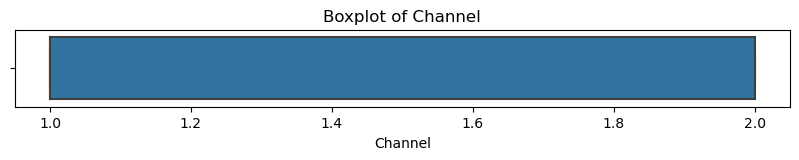

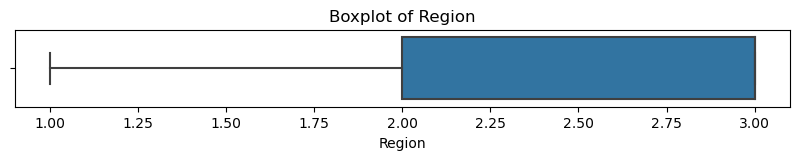

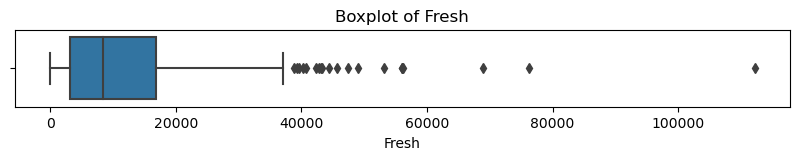

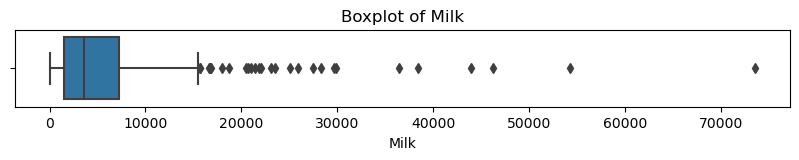

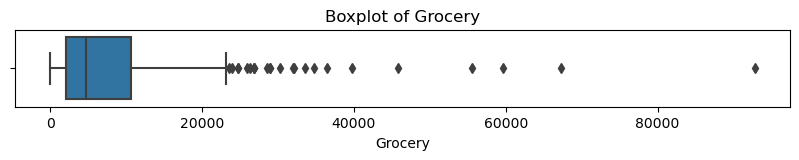

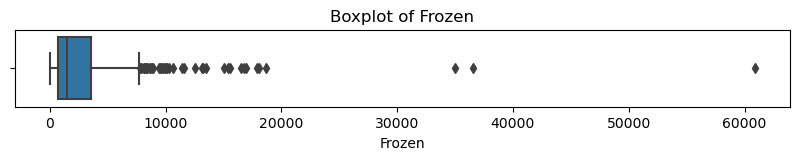

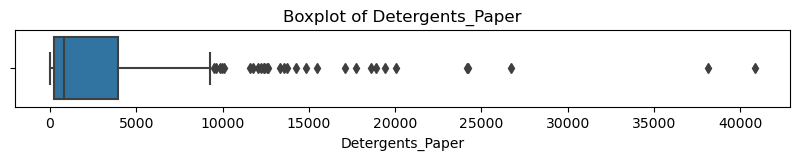

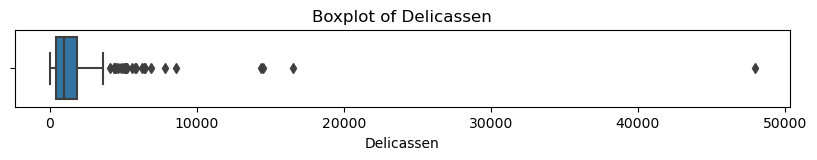

In [7]:
def boxplots(col):
    plt.figure(figsize=(10, 1))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()
    
for col in df.select_dtypes(exclude=['object', 'category']).columns:
    boxplots(col)

In [9]:
df.shape

(440, 8)

In [12]:
corr_matrix=df.corr()
corr_matrix

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Channel,1.000000,0.062028,-0.169172,0.460720,0.608792,-0.202046,0.636026,0.056011
Region,0.062028,1.000000,0.055287,0.032288,0.007696,-0.021044,-0.001483,0.045212
Fresh,-0.169172,0.055287,1.000000,0.100510,-0.011854,0.345881,-0.101953,0.244690
Milk,0.460720,0.032288,0.100510,1.000000,0.728335,0.123994,0.661816,0.406368
Grocery,0.608792,0.007696,-0.011854,0.728335,1.000000,-0.040193,0.924641,0.205497
Frozen,-0.202046,-0.021044,0.345881,0.123994,-0.040193,1.000000,-0.131525,0.390947
Detergents_Paper,0.636026,-0.001483,-0.101953,0.661816,0.924641,-0.131525,1.000000,0.069291
Delicassen,0.056011,0.045212,0.244690,0.406368,0.205497,0.390947,0.069291,1.000000


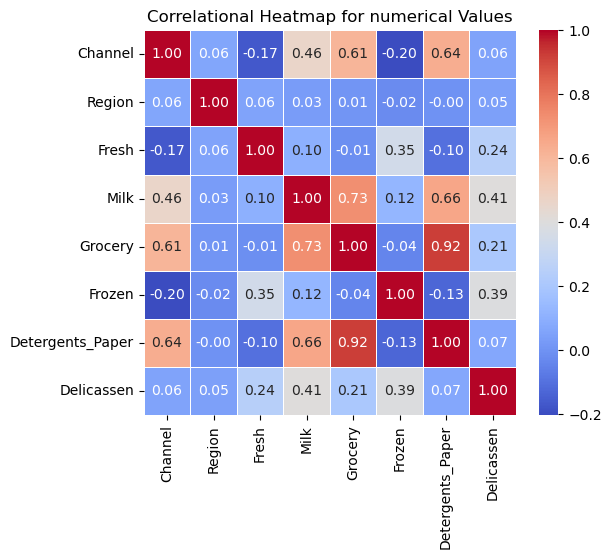

In [13]:
plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt=".2f",linewidths=0.5)
plt.title("Correlational Heatmap for numerical Values")
plt.show()

# KMeans Clustering

In [14]:
from sklearn.cluster import KMeans

In [15]:
wcss=[]
k_range=range(1,11)

In [16]:
from sklearn.preprocessing import StandardScaler

In [17]:
scaler=StandardScaler()

In [18]:
X_scaled=scaler.fit_transform(df)

In [19]:
for k in k_range:
    kmeans=KMeans(n_clusters=k,random_state=42,n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    

C:\Users\Pooja Mehta\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Pooja Mehta\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Pooja Mehta\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Pooja Mehta\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have

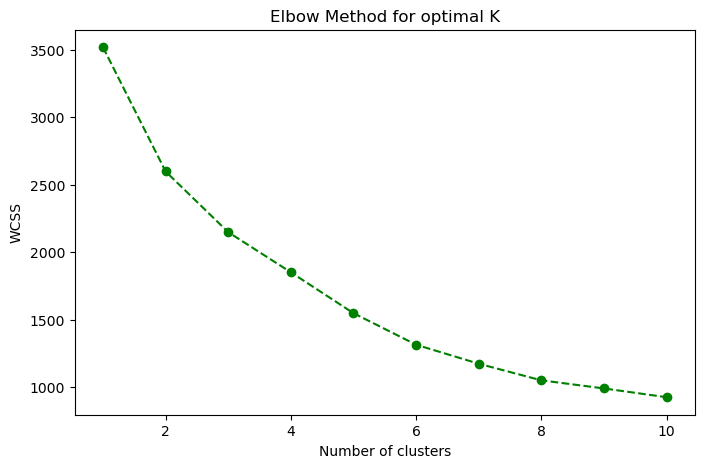

In [21]:
plt.figure(figsize=(8,5))
plt.plot(k_range,wcss, marker='o', linestyle='--',color='g')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method for optimal K')
plt.show()

In [22]:
optimal_k=5
kmeans=KMeans(n_clusters=5,random_state=42,n_init=10)
df['Cluster']= kmeans.fit_predict(X_scaled)

C:\Users\Pooja Mehta\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


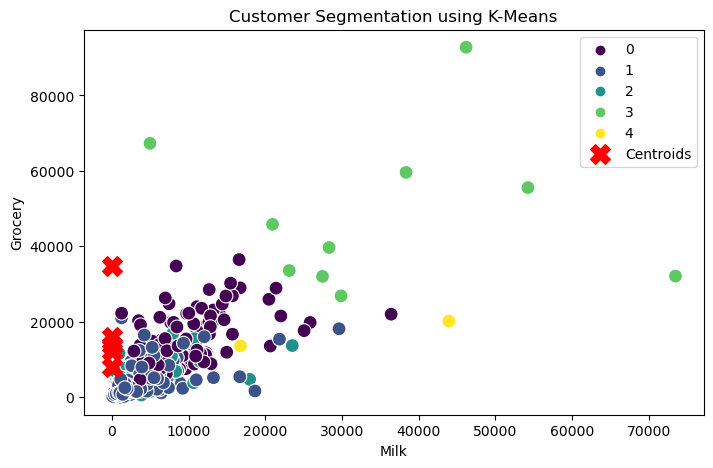

In [23]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Milk"], y=df["Grocery"], hue=df["Cluster"], palette="viridis", s=100)
plt.scatter(kmeans.cluster_centers_[:, 1] * scaler.scale_[1] + scaler.mean_[1],  # Rescaling centers
            kmeans.cluster_centers_[:, 2] * scaler.scale_[2] + scaler.mean_[2],
            s=200, c="red", marker="X", label="Centroids")
plt.xlabel("Milk")
plt.ylabel("Grocery")
plt.title("Customer Segmentation using K-Means")
plt.legend()
plt.show()

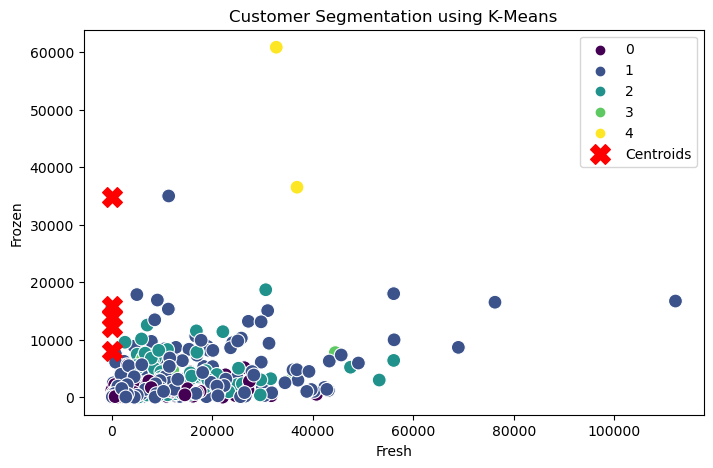

In [24]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Fresh"], y=df["Frozen"], hue=df["Cluster"], palette="viridis", s=100)
plt.scatter(kmeans.cluster_centers_[:, 1] * scaler.scale_[1] + scaler.mean_[1],  # Rescaling centers
            kmeans.cluster_centers_[:, 2] * scaler.scale_[2] + scaler.mean_[2],
            s=200, c="red", marker="X", label="Centroids")
plt.xlabel("Fresh")
plt.ylabel("Frozen")
plt.title("Customer Segmentation using K-Means")
plt.legend()
plt.show()

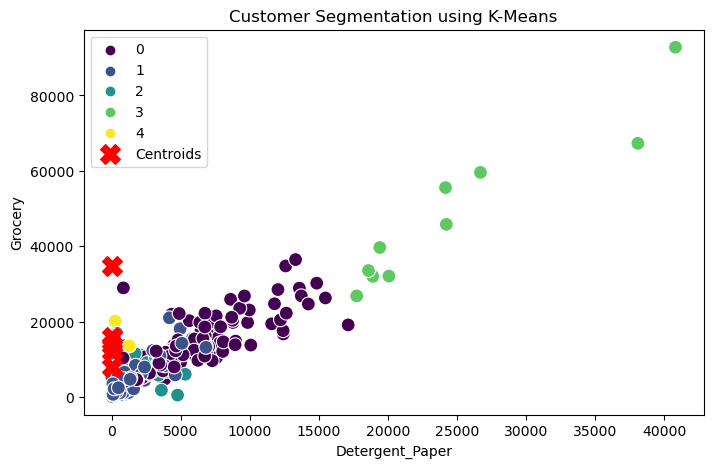

In [25]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Detergents_Paper"], y=df["Grocery"], hue=df["Cluster"], palette="viridis", s=100)
plt.scatter(kmeans.cluster_centers_[:, 1] * scaler.scale_[1] + scaler.mean_[1],  # Rescaling centers
            kmeans.cluster_centers_[:, 2] * scaler.scale_[2] + scaler.mean_[2],
            s=200, c="red", marker="X", label="Centroids")
plt.xlabel("Detergent_Paper")
plt.ylabel("Grocery")
plt.title("Customer Segmentation using K-Means")
plt.legend()
plt.show()

In [28]:
cluster_summary = df.groupby("Cluster")[["Region", "Milk", "Grocery","Frozen","Fresh","Delicassen","Detergents_Paper"]].mean()
cluster_summary

,Region,Milk,Grocery,Frozen,Fresh,Delicassen,Detergents_Paper
Cluster,,,,,,,
0,2.674603,9131.841270,14274.579365,1369.555556,8024.428571,1656.103175,6135.206349
1,3.000000,3297.379147,3814.625592,3490.218009,13891.473934,1301.658768,788.028436
2,1.307692,3254.714286,4130.923077,3458.252747,12183.945055,1149.934066,860.263736
3,2.500000,34708.500000,48536.900000,3054.600000,15964.900000,2942.800000,24875.200000
4,2.500000,30367.000000,16898.000000,48701.500000,34782.000000,26776.000000,755.500000


# DBSCAN

In [30]:
from sklearn.cluster import DBSCAN

In [31]:
dbscan=DBSCAN(eps=0.5,min_samples=5)
df["Cluster"] =dbscan.fit_predict(X_scaled)

In [32]:
df["Cluster"].unique()

array([-1,  1,  0,  3,  2,  4,  5,  6,  7], dtype=int64)

In [33]:
df["Cluster"].count()

440

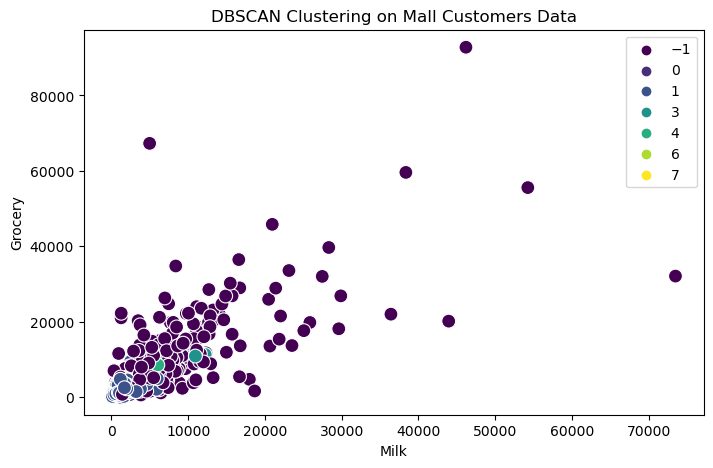

In [34]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Milk"], y=df["Grocery"], hue=df["Cluster"], palette="viridis", s=100)
plt.xlabel("Milk")
plt.ylabel("Grocery")
plt.title("DBSCAN Clustering on Mall Customers Data")
plt.legend()
plt.show()

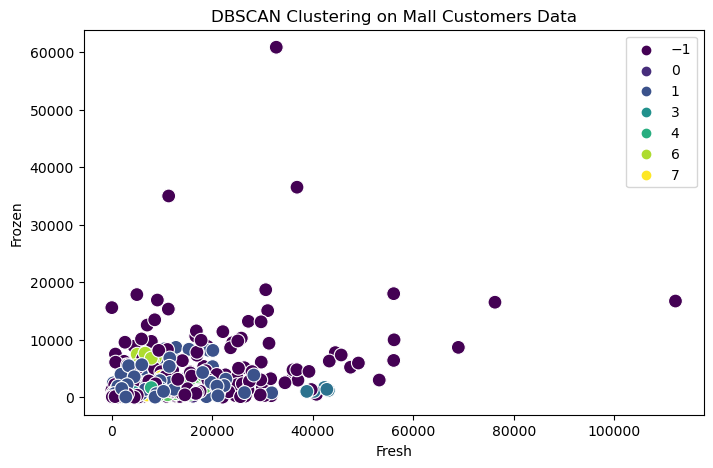

In [35]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Fresh"], y=df["Frozen"], hue=df["Cluster"], palette="viridis", s=100)
plt.xlabel("Fresh")
plt.ylabel("Frozen")
plt.title("DBSCAN Clustering on Mall Customers Data")
plt.legend()
plt.show()

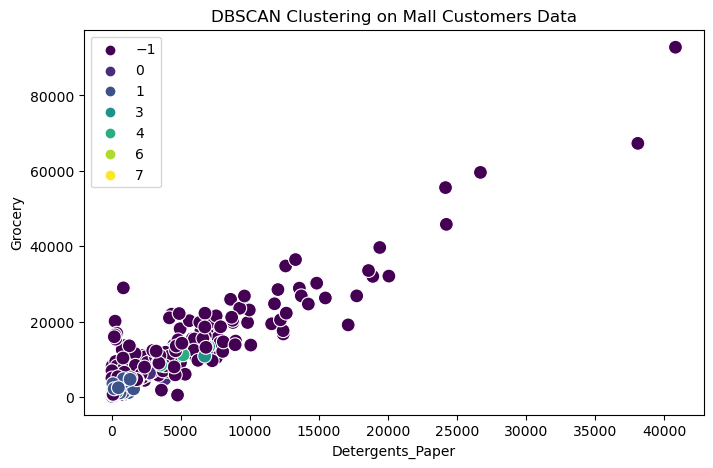

In [36]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Detergents_Paper"], y=df["Grocery"], hue=df["Cluster"], palette="viridis", s=100)
plt.xlabel("Detergents_Paper")
plt.ylabel("Grocery")
plt.title("DBSCAN Clustering on Mall Customers Data")
plt.legend()
plt.show()

# What are the disadvantages of k means clustering? What are the recent advancements or extensions for k means?

K-Means clustering requires specifying the number of clusters (k) beforehand and is sensitive to the initial centroid selection. It assumes spherical clusters, struggles with varying densities, and is affected by outliers. The algorithm does not perform well with categorical data and may produce uneven cluster sizes. To address these limitations, K-Means++ improves centroid initialization, while Mini-Batch K-Means enhances efficiency for large datasets. Fuzzy C-Means enables soft clustering, and K-Medoids makes the algorithm more robust to outliers. Kernel K-Means handles non-linear clusters, while Deep Embedded K-Means (DEKM) integrates deep learning for better feature extraction. These advancements make K-Means more scalable and adaptable for modern clustering tasks